#### This notebook demonstrates the use of InFoRM algorithms to mitigate bias for LINE embedding
InFoRM includes 3 algorithms, namely debiasing the input graph, debiasing the mining model and debiasing the mining result. We will show how to run all 3 algorithms for LINE in this notebook.

### Get vanilla embedding matrix first

In [1]:
# load necessary packages
import os, pickle
import load_graph, utils
import numpy as np
import networkx as nx
import sklearn.preprocessing as skpp
from tqdm import tqdm

dataset_name = 'Facebook'

base_dir = f'result/line/{dataset_name}'

os.makedirs(base_dir, exist_ok=True)
os.makedirs(f'{base_dir}/graph', exist_ok=True)
os.makedirs(f'{base_dir}/model', exist_ok=True)
os.makedirs(f'{base_dir}/result', exist_ok=True)
print('Packages loaded.')

Packages loaded.


In [2]:
# from vanilla_line import *
class LINE:
    def __init__(self, dimension=128, ratio=3200, negative=5,
                 batch_size=1000, init_lr=0.025, seed=None):
        self.dimension  = dimension
        self.ratio      = ratio
        self.negative   = negative
        self.batch_size = batch_size
        self.init_lr    = init_lr
        if seed is not None:
            np.random.seed(seed)

    def train(self, graph):
        self.graph       = graph
        self.is_directed = nx.is_directed(graph)
        self.num_node    = graph.number_of_nodes()
        self.num_sampling_edge = self.ratio * self.num_node

        node2id = {node: vid for vid, node in enumerate(graph.nodes())}
        self.edges = [[node2id[e[0]], node2id[e[1]]] for e in graph.edges()]

        # FIX: 'weight' must be a string key
        self.edges_prob = np.asarray([graph[u][v].get('weight', 1.0) for u, v in graph.edges()])
        self.edges_prob /= np.sum(self.edges_prob)
        self.edges_table, self.edges_prob = alias_setup(self.edges_prob)

        degree_weight = np.zeros(self.num_node)
        for u, v in graph.edges():
            degree_weight[node2id[u]] += graph[u][v].get('weight', 1.0)  # FIX
            if not self.is_directed:
                degree_weight[node2id[v]] += graph[u][v].get('weight', 1.0)  # FIX
        self.node_prob  = np.power(degree_weight, 0.75)
        self.node_prob /= np.sum(self.node_prob)
        self.node_table, self.node_prob = alias_setup(self.node_prob)

        self.emb_vertex = (np.random.random((self.num_node, self.dimension)) - 0.5) / self.dimension
        self._train_line()
        self.embeddings = skpp.normalize(self.emb_vertex, 'l2')  # FIX: string 'l2'
        return self.embeddings

    def _update(self, vec_u, vec_v, vec_error, label):
        f = 1 / (1 + np.exp(-np.sum(vec_u * vec_v, axis=1)))
        g = (self.lr * (label - f)).reshape((len(label), 1))
        vec_error += g * vec_v
        vec_v     += g * vec_u

    def _train_line(self):
        self.lr    = self.init_lr
        batch_size = self.batch_size
        num_batch  = int(self.num_sampling_edge / batch_size)
        # FIX: dùng tqdm thay vì print thủ công
        for b in tqdm(range(num_batch), desc='Training LINE'):
            self.lr = self.init_lr * max((1 - b / num_batch), 0.0001)
            u, v    = [0]*batch_size, [0]*batch_size
            for i in range(batch_size):
                edge_id = alias_draw(self.edges_table, self.edges_prob)
                u[i], v[i] = self.edges[edge_id]
                if not self.is_directed and np.random.rand() > 0.5:
                    v[i], u[i] = self.edges[edge_id]
            vec_error = np.zeros((batch_size, self.dimension))
            label     = np.asarray([1]*batch_size)
            target    = np.asarray(v)
            for j in range(self.negative + 1):
                if j != 0:
                    label = np.zeros(batch_size, dtype=int)
                    for i in range(batch_size):
                        target[i] = alias_draw(self.node_table, self.node_prob)
                self._update(self.emb_vertex[u], self.emb_vertex[target], vec_error, label)
            self.emb_vertex[u] += vec_error

print('LINE class ready.')


def alias_setup(probs):
    K = len(probs)
    q = np.zeros(K)
    J = np.zeros(K, dtype=np.int64)   # FIX: np.int is deprecated → np.int64
    smaller, larger = [], []
    for kk, prob in enumerate(probs):
        q[kk] = K * prob
        if q[kk] < 1.0: smaller.append(kk)
        else:            larger.append(kk)
    while smaller and larger:
        small, large = smaller.pop(), larger.pop()
        J[small] = large
        q[large] = q[large] + q[small] - 1.0
        if q[large] < 1.0: smaller.append(large)
        else:               larger.append(large)
    return J, q

def alias_draw(J, q):
    K  = len(J)
    kk = int(np.floor(np.random.rand() * K))
    return kk if np.random.rand() < q[kk] else J[kk]

LINE class ready.


In [3]:
# def vanilla(name, ratio=3200, seed=0):
#     try:
#         with open('result/line/vanilla.pickle', 'rb') as f:
#             edict = pickle.load(f)
#     except:
#         edict = dict()

#     data      = load_graph.read_pickle(name)
#     adj_train = data['adjacency_train']
#     graph     = nx.from_scipy_sparse_array(adj_train, create_using=nx.Graph(), edge_attribute='weight')

#     print(f'Training vanilla LINE on [{name}]...')
#     model        = LINE(ratio=ratio, seed=seed)
#     edict[name]  = model.train(graph)

#     with open('result/line/vanilla.pickle', 'wb') as f:
#         pickle.dump(edict, f, protocol=pickle.HIGHEST_PROTOCOL)
#     print('Saved: result/line/vanilla.pickle')
    
    
def vanilla(name, ratio=3200, seed=0):
    # 1. Khai báo đường dẫn động dựa vào tham số 'name'
    file_path = f'result/line/{name}/vanilla.pickle'
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    try:
        with open('result/line/vanilla.pickle', 'rb') as f:
            edict = pickle.load(f)
    except:
        edict = dict()

    data      = load_graph.read_pickle(name)
    adj_train = data['adjacency_train']
    graph     = nx.from_scipy_sparse_array(adj_train, create_using=nx.Graph(), edge_attribute='weight')

    print(f'Training vanilla LINE on [{name}]...')
    model        = LINE(ratio=ratio, seed=seed)
    edict[name]  = model.train(graph)

    # 3. Ghi file vào đúng thư mục riêng của dataset
    with open(file_path, 'wb') as f:
        pickle.dump(edict, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'Saved: {file_path}')

In [4]:
vanilla(name='Facebook', ratio=3200, seed=0)

Training vanilla LINE on [Facebook]...


Training LINE: 100%|██████████| 71910/71910 [36:39<00:00, 32.70it/s] 


Saved: result/line/Facebook/vanilla.pickle


### Let's debias the input graph

In [ ]:
# load debias model
from method.debias_graph import DebiasGraph

In [6]:
def debias_input_graph(name, alpha=0., lr=0., metric=None):
    # load dataset
    
    data = load_graph.read_pickle(name)
    init_adj = data['adjacency_train']

    # build similarity matrix
    sim = utils.filter_similarity_matrix(utils.get_similarity_matrix(init_adj, metric=metric), sigma=0.75)

    # debias LINE
    FairGraph = DebiasGraph()
    adj = FairGraph.line(init_adj, sim, alpha, maxiter=100, lr=lr, tol=1e-6)
    graph = nx.from_scipy_sparse_array(adj, create_using=nx.Graph(), edge_attribute='weight')
    model = LINE(ratio=3200, seed=0)
    embs = model.train(graph)

    print('dataset: {}\tmetric: {} similarity'.format(name, metric))
    print('Finished!')

    return embs

In [7]:
dataset_name = 'Facebook'
result_jaccard = dict()
result_jaccard[dataset_name] = debias_input_graph(name=dataset_name, alpha=10, lr=0.025, metric='jaccard')

os.makedirs(f'result/line/{dataset_name}/graph', exist_ok=True)
# Lưu file vào đúng "nhà" của dataset
with open(f'result/line/{dataset_name}/graph/jaccard.pickle', 'wb') as f:
    pickle.dump(result_jaccard, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Đã lưu kết quả Jaccard cho tập {dataset_name}")


# ==========================================
# 2. Chạy với độ đo COSINE SIMILARITY
# ==========================================
result_cosine = dict()
result_cosine[dataset_name] = debias_input_graph(name=dataset_name, alpha=10, lr=0.025, metric='cosine')

# Lưu file vào đúng "nhà" của dataset
with open(f'result/line/{dataset_name}/graph/cosine.pickle', 'wb') as f:
    pickle.dump(result_cosine, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Đã lưu kết quả Cosine cho tập {dataset_name}")

Training LINE: 100%|██████████| 71910/71910 [29:48<00:00, 40.20it/s] 


dataset: Facebook	metric: jaccard similarity
Finished!
Đã lưu kết quả Jaccard cho tập Facebook


Training LINE: 100%|██████████| 71910/71910 [27:28<00:00, 43.63it/s] 


dataset: Facebook	metric: cosine similarity
Finished!
Đã lưu kết quả Cosine cho tập Facebook


### Let's debias the mining model

In [8]:
# load debias model
from method.debias_model import DebiasModel

In [9]:
def debias_mining_model(name, alpha=0., metric=None):
    # load dataset
    data = load_graph.read_pickle(name)
    adj_train = data['adjacency_train']
    graph = nx.from_scipy_sparse_array(adj_train, create_using=nx.Graph(), edge_attribute='weight')

    # build similarity matrix
    sim = utils.filter_similarity_matrix(utils.get_similarity_matrix(adj_train, metric=metric), sigma=0.75)

    # debias LINE
    FairModel = DebiasModel()
    embs = FairModel.line(
        graph, sim, alpha,
        dimension=128, ratio=3200, negative=5,
        init_lr=0.025, batch_size=1000, seed=0
    )

    print('dataset: {}\tmetric: {} similarity'.format(name, metric))
    print('Finished!')

    return embs

In [11]:
alpha = 0.5
dataset_name = 'Facebook'
result_jaccard = dict()
result_jaccard[dataset_name] = debias_mining_model(name=dataset_name, alpha=10, metric='jaccard')
os.makedirs(f'result/line/{dataset_name}/graph', exist_ok=True)
# Lưu file vào đúng "nhà" của dataset
with open(f'result/line/{dataset_name}/graph/jaccard.pickle', 'wb') as f:
    pickle.dump(result_jaccard, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Đã lưu kết quả Jaccard cho tập {dataset_name}")


# ==========================================
# 2. Chạy với độ đo COSINE SIMILARITY
# ==========================================
result_cosine = dict()
result_cosine[dataset_name] = debias_mining_model(name=dataset_name, alpha=10, metric='cosine')

# Lưu file vào đúng "nhà" của dataset
with open(f'result/line/{dataset_name}/graph/cosine.pickle', 'wb') as f:
    pickle.dump(result_cosine, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Đã lưu kết quả Cosine cho tập {dataset_name}")

dataset: Facebook	metric: jaccard similarity
Finished!
Đã lưu kết quả Jaccard cho tập Facebook
dataset: Facebook	metric: cosine similarity
Finished!
Đã lưu kết quả Cosine cho tập Facebook


### Let's debias the mining result

In [12]:
# load debias model
from method.debias_result import DebiasResult

In [13]:
def debias_mining_result(name, vanilla, alpha=0., metric=None):
    
    file_path = f'result/line/{name}/result/{metric}.pickle'
    # vanilla embeddings
    embs = vanilla[name]

    # load dataset
    data = load_graph.read_pickle(name)
    adj_train = data['adjacency_train']

    # build similarity matrix
    sim = utils.filter_similarity_matrix(utils.get_similarity_matrix(adj_train, metric=metric), sigma=0.75)

    # debias LINE
    FairResult = DebiasResult()
    embs = FairResult.fit(embs, sim, alpha)

    print('dataset: {}\tmetric: {} similarity'.format(name, metric))
    print(f'Finished & Saved: {file_path}\n')

    return embs

In [14]:

alpha = 0.5
dataset_name = 'Facebook'
os.makedirs(f'result/line/{dataset_name}/result', exist_ok=True)
# ==========================================
# 1. Đọc kết quả Vanilla từ đúng thư mục của dataset
# ==========================================
vanilla_path = f'result/line/{dataset_name}/vanilla.pickle'
with open(vanilla_path, 'rb') as f:
    vanilla = pickle.load(f)
print(f"✅ Đã nạp thành công vector Vanilla của tập {dataset_name} để chuẩn bị giải độc.")

# ==========================================
# 2. Chạy can thiệp kết quả với độ đo JACCARD INDEX
# ==========================================
result_jaccard = dict()
result_jaccard[dataset_name] = debias_mining_result(name=dataset_name, vanilla=vanilla, alpha=alpha, metric='jaccard')

# Lưu file vào đúng "nhà" của dataset
with open(f'result/line/{dataset_name}/result/jaccard.pickle', 'wb') as f:
    pickle.dump(result_jaccard, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"✅ Đã lưu Debias Result (Jaccard) cho tập {dataset_name}")

# ==========================================
# 3. Chạy can thiệp kết quả với độ đo COSINE SIMILARITY 
# ==========================================
result_cosine = dict()
result_cosine[dataset_name] = debias_mining_result(name=dataset_name, vanilla=vanilla, alpha=alpha, metric='cosine')

# Lưu file vào đúng "nhà" của dataset
with open(f'result/line/{dataset_name}/result/cosine.pickle', 'wb') as f:
    pickle.dump(result_cosine, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"✅ Đã lưu Debias Result (Cosine) cho tập {dataset_name}")

✅ Đã nạp thành công vector Vanilla của tập Facebook để chuẩn bị giải độc.
dataset: Facebook	metric: jaccard similarity
Finished & Saved: result/line/Facebook/result/jaccard.pickle

✅ Đã lưu Debias Result (Jaccard) cho tập Facebook
dataset: Facebook	metric: cosine similarity
Finished & Saved: result/line/Facebook/result/cosine.pickle

✅ Đã lưu Debias Result (Cosine) cho tập Facebook


### Now, let's see how much we debiased and how good debiased results are

In [15]:
# load evaluation functions
from evaluate.line import evaluate

In [16]:
# evaluate(name='ppi', metric='jaccard', task='graph')
# evaluate(name='ppi', metric='cosine', task='graph')
# evaluate(name='ppi', metric='jaccard', task='model')
# evaluate(name='ppi', metric='cosine', task='model')
# evaluate(name='ppi', metric='jaccard', task='result')
# evaluate(name='ppi', metric='cosine', task='result')
lpha = 0.5
dataset_name = 'Facebook'


os.makedirs(f'result/line/{dataset_name}/model', exist_ok=True)

print(f" dữ liệu Debias Model LINE trên tập [{dataset_name}]...")

# ==========================================
# 1. Chạy can thiệp MÔ HÌNH với độ đo JACCARD INDEX
# ==========================================
result_jaccard = dict()
result_jaccard[dataset_name] = debias_mining_model(name=dataset_name, alpha=alpha, metric='jaccard')

with open(f'result/line/{dataset_name}/model/jaccard.pickle', 'wb') as f:
    pickle.dump(result_jaccard, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f" Đã lưu Debias Model (Jaccard) cho tập {dataset_name}")

# ==========================================
# 2. Chạy can thiệp MÔ HÌNH với độ đo COSINE SIMILARITY 
# ==========================================
result_cosine = dict()
result_cosine[dataset_name] = debias_mining_model(name=dataset_name, alpha=alpha, metric='cosine')

with open(f'result/line/{dataset_name}/model/cosine.pickle', 'wb') as f:
    pickle.dump(result_cosine, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Đã lưu Debias Model (Cosine) cho tập {dataset_name}")

 dữ liệu Debias Model LINE trên tập [Facebook]...
dataset: Facebook	metric: jaccard similarity
Finished!
 Đã lưu Debias Model (Jaccard) cho tập Facebook
dataset: Facebook	metric: cosine similarity
Finished!
Đã lưu Debias Model (Cosine) cho tập Facebook


Đang tổng hợp số liệu cho tập Facebook...
{'dataset': 'Facebook', 'metric': 'jaccard similarity', 'task': 'debias the input graph', 'diff': np.float64(0.7508874089896498), 'roc-auc': (np.float64(0.9459661742074484), np.float64(0.9490048596149243)), 'f1': (0.8876608187134503, 0.8935672514619883), 'bias': {'train': [np.float64(0.02174405810676827)], 'validation': [np.float64(0.07062435935983813)], 'test': [np.float64(0.06719573505146748)]}}
{'dataset': 'Facebook', 'metric': 'cosine similarity', 'task': 'debias the input graph', 'diff': np.float64(0.7811440399843812), 'roc-auc': (np.float64(0.9459661742074484), np.float64(0.9484915529564651)), 'f1': (0.8876608187134503, 0.8915204678362573), 'bias': {'train': [np.float64(0.020226736629652242)], 'validation': [np.float64(0.08649610985922485)], 'test': [np.float64(0.08336964465064722)]}}
{'dataset': 'Facebook', 'metric': 'jaccard similarity', 'task': 'debias the mining model', 'diff': np.float64(0.3232414823401895), 'roc-auc': (np.float64(0.

,task,metric,diff,roc-auc,f1,bias,label
0,graph,jaccard,0.750887,0.949005,0.893567,0.067196,graph (jaccard)
1,graph,cosine,0.781144,0.948492,0.891520,0.083370,graph (cosine)
2,model,jaccard,0.323241,0.954400,0.902339,0.741010,model (jaccard)
3,model,cosine,0.442424,0.956684,0.906082,0.804792,model (cosine)
4,result,jaccard,0.303543,0.950320,0.889766,0.907214,result (jaccard)
5,result,cosine,0.415997,0.953109,0.891053,0.946554,result (cosine)


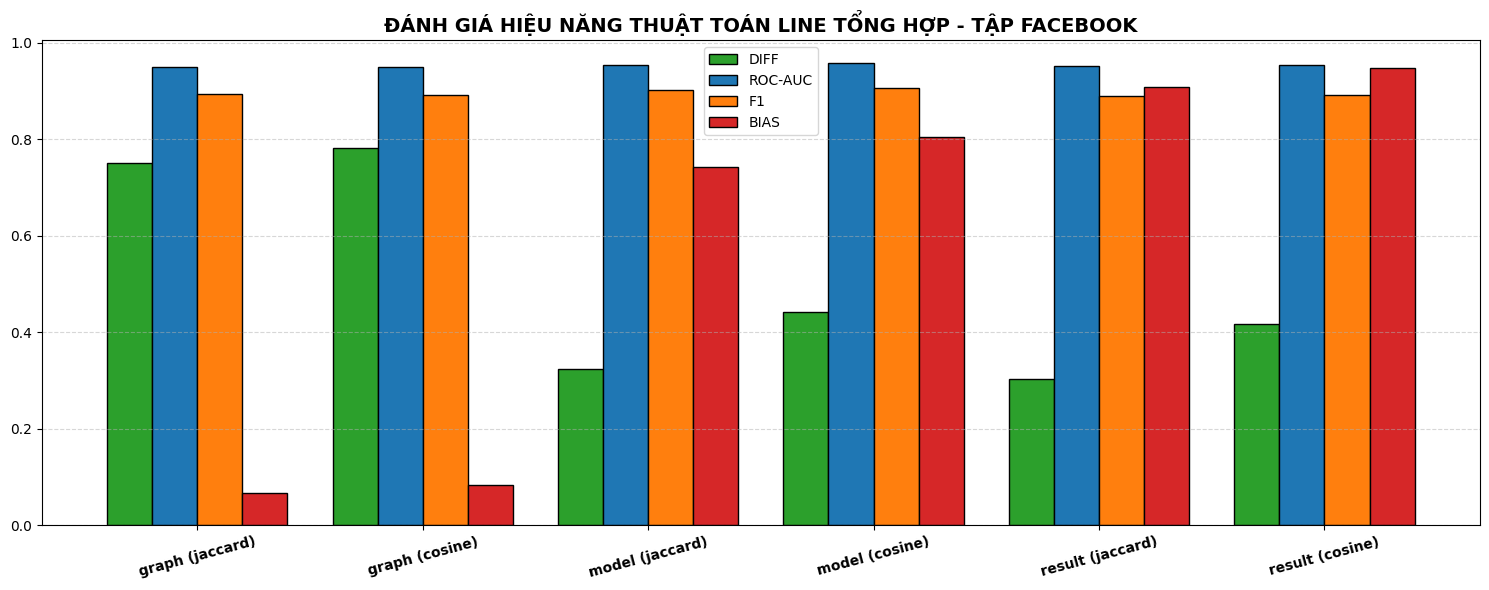

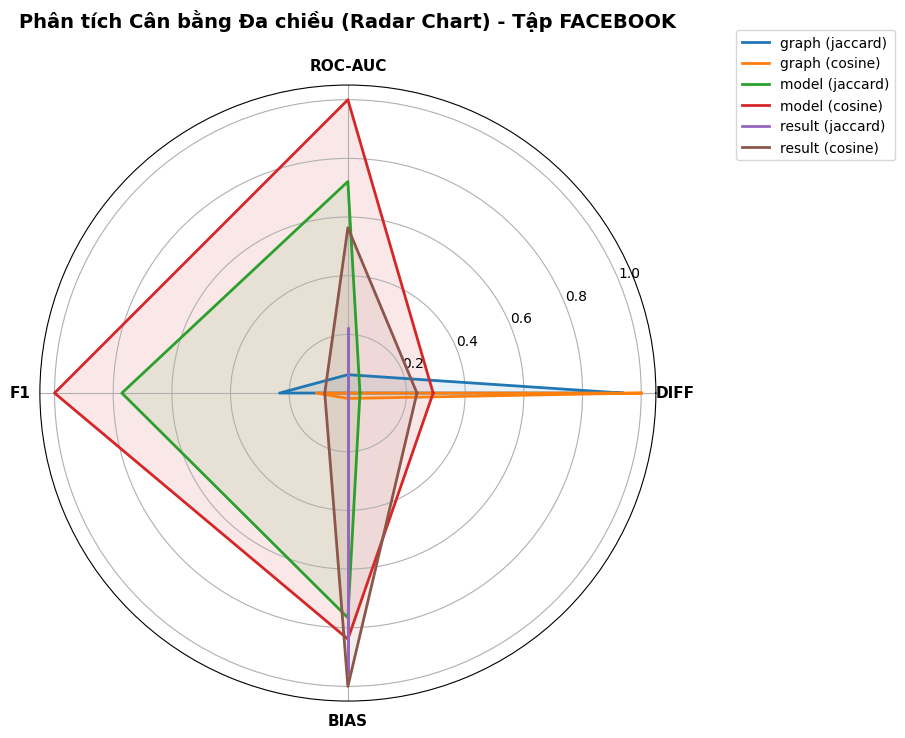

Đã xuất thành công 2 ảnh biểu đồ vào file: LINE_Facebook_BarChart.png và LINE_Facebook_RadarChart.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# KHAI BÁO DATASET ĐỘNG
# =========================
dataset_name = 'Facebook' # Có thể đổi thành 'ppi' hoặc 'CA-AstroPh' tùy ý

# =========================
# RUN EVALUATION VÀ GẮP SỐ LIỆU
# =========================
results = []
configs = [
    ('jaccard', 'graph'), ('cosine', 'graph'),
    ('jaccard', 'model'), ('cosine', 'model'),
    ('jaccard', 'result'), ('cosine', 'result')
]

print(f"Đang tổng hợp số liệu cho tập {dataset_name}...")

for metric, task in configs:
    # Sửa chữ 'ppi' thành biến dataset_name
    r = evaluate(name=dataset_name, metric=metric, task=task)
    
    if r: # Kiểm tra an toàn nhỡ r bị rỗng
        row = {
            'task': task,
            'metric': metric,
            'diff': float(r.get('diff', 0)),
            # Luôn dùng [-1] để gắp con số cuối cùng (tức là mô hình sau khi đã giải độc)
            'roc-auc': float(r['roc-auc'][-1]) if 'roc-auc' in r else 0.0,    
            'f1': float(r['f1'][-1]) if 'f1' in r else 0.0,              
            'bias': float(r['bias']['test'][-1]) if 'bias' in r and 'test' in r['bias'] else 0.0 
        }
        results.append(row)

# =========================
# XÂY DỰNG DATAFRAME
# =========================
df = pd.DataFrame(results)
df['label'] = df['task'] + " (" + df['metric'] + ")"
print("\n--- BẢNG SỐ LIỆU TỔNG HỢP ---")
display(df)

# =========================
# VẼ BAR CHART (BIỂU ĐỒ CỘT)
# =========================
metrics = ['diff', 'roc-auc', 'f1', 'bias']

x = np.arange(len(df))
width = 0.2

plt.figure(figsize=(15, 6))
# Thêm màu sắc phân biệt rõ ràng cho các cột
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] 

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, df[metric], width=width, label=metric.upper(), color=colors[i], edgecolor='black')

plt.xticks(x + width*1.5, df['label'], rotation=15, fontweight='bold')
plt.title(f"ĐÁNH GIÁ HIỆU NĂNG THUẬT TOÁN LINE TỔNG HỢP - TẬP {dataset_name.upper()}", fontweight='bold', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'LINE_{dataset_name}_BarChart.png', dpi=300) # Xuất ảnh nét căng cho báo cáo
plt.show()

# =========================
# VẼ RADAR CHART (BIỂU ĐỒ MẠNG NHỆN)
# =========================
radar_df = df.copy()

# Normalize (Chuẩn hóa) để vẽ biểu đồ mạng nhện
for col in metrics:
    min_val = radar_df[col].min()
    max_val = radar_df[col].max()
    if max_val != min_val:
        radar_df[col] = (radar_df[col] - min_val) / (max_val - min_val)
    else:
        radar_df[col] = 0

categories = [m.upper() for m in metrics]
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i in range(len(radar_df)):
    values = radar_df.loc[i, metrics].tolist()
    values += values[:1]
    
    ax.plot(angles, values, linewidth=2, label=radar_df.loc[i, 'label'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontweight='bold', fontsize=11)
plt.title(f"Phân tích Cân bằng Đa chiều (Radar Chart) - Tập {dataset_name.upper()}", fontweight='bold', fontsize=14, y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10)

plt.savefig(f'LINE_{dataset_name}_RadarChart.png', dpi=300, bbox_inches='tight') # Xuất ảnh mạng nhện
plt.show()

print(f"Đã xuất thành công 2 ảnh biểu đồ vào file: LINE_{dataset_name}_BarChart.png và LINE_{dataset_name}_RadarChart.png")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================
# 1. KHAI BÁO & LẤY SỐ LIỆU
# =========================
dataset_name = 'Facebook'
results = []
configs = [
    ('jaccard', 'graph'), ('cosine', 'graph'),
    ('jaccard', 'model'), ('cosine', 'model'),
    ('jaccard', 'result'), ('cosine', 'result')
]

print(f"⏳ Đang tổng hợp số liệu cho tập {dataset_name}...")
for metric, task in configs:
    r = evaluate(name=dataset_name, metric=metric, task=task)
    if r:
        row = {
            'task': task.upper(),
            'metric': metric.capitalize(),
            'diff': float(r.get('diff', 0)),
            'roc-auc': float(r['roc-auc'][-1]) if 'roc-auc' in r else 0.0,    
            'f1': float(r['f1'][-1]) if 'f1' in r else 0.0,              
            'bias': float(r['bias']['test'][-1]) if 'bias' in r and 'test' in r['bias'] else 0.0 
        }
        results.append(row)

df = pd.DataFrame(results)
df['label'] = df['task'] + " (" + df['metric'] + ")"

# =========================
# 2. VẼ VÀ LƯU BIỂU ĐỒ CỘT (BAR CHART)
# =========================
metrics = ['diff', 'roc-auc', 'f1', 'bias']
x = np.arange(len(df))
width = 0.2
plt.figure(figsize=(12, 6))
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] 

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, df[metric], width=width, label=metric.upper(), color=colors[i], edgecolor='black')

plt.xticks(x + width*1.5, df['label'], rotation=15, fontweight='bold')
plt.title(f"ĐÁNH GIÁ HIỆU NĂNG LINE TỔNG HỢP - TẬP {dataset_name.upper()}", fontweight='bold', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

bar_chart_path = f'LINE_{dataset_name}_BarChart.png'
plt.savefig(bar_chart_path, dpi=200) # Lưu ảnh Cột
plt.close() # Đóng plot để vẽ hình mạng nhện

# =========================
# 3. VẼ VÀ LƯU BIỂU ĐỒ MẠNG NHỆN (RADAR CHART)
# =========================
radar_df = df.copy()
for col in metrics: # Normalize
    min_val, max_val = radar_df[col].min(), radar_df[col].max()
    radar_df[col] = (radar_df[col] - min_val) / (max_val - min_val) if max_val != min_val else 0

categories = [m.upper() for m in metrics]
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i in range(len(radar_df)):
    values = radar_df.loc[i, metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=radar_df.loc[i, 'label'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontweight='bold', fontsize=11)
plt.title(f"Phân tích Đa chiều (Radar Chart) - Tập {dataset_name.upper()}", fontweight='bold', fontsize=14, y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

radar_chart_path = f'LINE_{dataset_name}_RadarChart.png'
plt.savefig(radar_chart_path, dpi=200, bbox_inches='tight') # Lưu ảnh Nhện
plt.close()

# =========================
# 4. XUẤT FILE EXCEL KÈM HÌNH ẢNH NHÚNG
# =========================
excel_file = f'LINE_{dataset_name}_Dashboard.xlsx'
writer = pd.ExcelWriter(excel_file, engine='xlsxwriter')

# Ghi bảng số liệu vào Sheet tên là 'Results'
df.to_excel(writer, sheet_name='Results', index=False)
workbook = writer.book
worksheet = writer.sheets['Results']

# Chỉnh độ rộng cột cho đẹp
worksheet.set_column('A:F', 15)

# CHÈN HÌNH ẢNH VÀO EXCEL (Gắn vào ô G2 và G30)
worksheet.insert_image('H2', bar_chart_path, {'x_scale': 0.65, 'y_scale': 0.65})
worksheet.insert_image('H32', radar_chart_path, {'x_scale': 0.7, 'y_scale': 0.7})

writer.close()

print(f"🎉 THÀNH CÔNG! Thầy đã gom tất cả số liệu và biểu đồ vào 1 file duy nhất.")
print(f"📁 Hãy mở file: {excel_file} để xem kết quả nhé!")

⏳ Đang tổng hợp số liệu cho tập Facebook...
{'dataset': 'Facebook', 'metric': 'jaccard similarity', 'task': 'debias the input graph', 'diff': np.float64(0.7508874089896498), 'roc-auc': (np.float64(0.9459661742074484), np.float64(0.9490048596149243)), 'f1': (0.8876608187134503, 0.8935672514619883), 'bias': {'train': [np.float64(0.02174405810676827)], 'validation': [np.float64(0.07062435935983813)], 'test': [np.float64(0.06719573505146748)]}}
{'dataset': 'Facebook', 'metric': 'cosine similarity', 'task': 'debias the input graph', 'diff': np.float64(0.7811440399843812), 'roc-auc': (np.float64(0.9459661742074484), np.float64(0.9484915529564651)), 'f1': (0.8876608187134503, 0.8915204678362573), 'bias': {'train': [np.float64(0.020226736629652242)], 'validation': [np.float64(0.08649610985922485)], 'test': [np.float64(0.08336964465064722)]}}
{'dataset': 'Facebook', 'metric': 'jaccard similarity', 'task': 'debias the mining model', 'diff': np.float64(0.3232414823401895), 'roc-auc': (np.float64(